# Notebook 03: Two-Tower Model Training

## Purpose

This notebook trains the Two-Tower (Dual Encoder) model that powers candidate generation in our recommendation system. The model learns to embed users and movies into a shared 64-dimensional space where dot product measures relevance.

## What we produce

| Output | Description | Used by |
|--------|-------------|----------|
| `models/two_tower_model.pt` | Trained PyTorch model (both towers) | Embedding extraction, cold-start |
| `models/faiss_index.bin` | FAISS IndexFlatIP with 21K item embeddings | Online candidate retrieval |
| `models/item_embeddings.npy` | 21,081 x 64 item embeddings | Session-based cold-start averaging |
| `models/user_embeddings.npy` | 138,001 x 64 user embeddings | Embedding KV for online lookup |

## What we consume

From Notebook 02:
- `data/processed/two_tower_train.parquet` - 69M (user_idx, movie_idx, label) pairs
- `data/processed/val_set.parquet` - 2.3M validation interactions with labels
- `data/processed/user_features.parquet` - 138,001 users x 24 features
- `data/processed/item_features.parquet` - 21,081 movies x 73 features
- `data/processed/metadata.pkl` - ID mappings, dimensions, counts

## Architecture recap

```
User Tower:                          Item Tower:
  user_idx --> Embedding(64)           movie_idx --> Embedding(64)
  concat with user_features(24)        concat with item_features(73)
  --> Linear(88, 128) + ReLU           --> Linear(137, 128) + ReLU
  --> Linear(128, 64) + ReLU           --> Linear(128, 64) + ReLU
  --> Linear(64, 64)                   --> Linear(64, 64)
  --> L2 Normalize                     --> L2 Normalize
  Output: 64-dim unit vector           Output: 64-dim unit vector

Score = dot(user_emb, item_emb) * sqrt(64)
Loss  = BCE(sigmoid(score), label)
```

The sqrt(64) scaling keeps logits in a useful range for sigmoid. Without it, dot products of unit vectors (range [-1, 1]) produce very weak gradients through sigmoid.

In [1]:
import numpy as np
import pandas as pd
import pickle
import time
import os
from pathlib import Path

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
import faiss

DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

# Use CPU for analysis (training was done on MPS via scripts/train_two_tower.py)
device = torch.device('cpu')
print(f'Device: {device} (analysis only - training ran on MPS)')
print(f'PyTorch: {torch.__version__}')

Device: cpu (analysis only - training ran on MPS)
PyTorch: 2.11.0


## Section 1: Load Data and Feature Matrices

We load the pre-computed feature matrices and training pairs. The key design decision is how we store features for fast lookup during training: we convert the DataFrames into contiguous numpy arrays indexed by user_idx and movie_idx, so a single integer index gives us the feature vector in O(1).

The training data (69M pairs) is kept as numpy arrays and accessed via shuffled index permutations rather than through PyTorch DataLoader. This avoids the memory overhead of DataLoader's RandomSampler creating a 69M-element int64 permutation tensor.

In [2]:
with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

n_users = metadata['n_users']
n_movies = metadata['n_movies']
user_feature_dim = metadata['user_feature_dim']
item_feature_dim = metadata['item_feature_dim']
idx2user = metadata['idx2user']
idx2movie = metadata['idx2movie']
user2idx = metadata['user2idx']
movie2idx = metadata['movie2idx']

print(f'Users: {n_users:,} (indices 0 to {n_users-1}, where 0 is reserved/unknown)')
print(f'Movies: {n_movies:,} (indices 0 to {n_movies-1}, where 0 is reserved/unknown)')
print(f'User feature dim: {user_feature_dim}')
print(f'Item feature dim: {item_feature_dim}')

Users: 138,002 (indices 0 to 138001, where 0 is reserved/unknown)
Movies: 21,082 (indices 0 to 21081, where 0 is reserved/unknown)
User feature dim: 24
Item feature dim: 73


### Building contiguous feature arrays for O(1) lookup

The DataFrames from Notebook 02 are indexed by original user/movie IDs (sparse integers like userId=162541). For training, we need features looked up by dense integer indices (0 to 138,001). We pre-allocate zero-filled numpy arrays of shape (n_users, 24) and (n_movies, 73), then fill each row at position `user2idx[user_id]` with that user's feature vector.

After this, fetching User #42's 24 features during training is just `user_feature_matrix[42]` -- a single array indexing operation, not a DataFrame lookup. This matters when we do 69 million lookups per epoch.

In [3]:
# Build contiguous feature arrays indexed by user_idx / movie_idx
user_features_df = pd.read_parquet(DATA_DIR / 'user_features.parquet')
item_features_df = pd.read_parquet(DATA_DIR / 'item_features.parquet')

user_feature_matrix = np.zeros((n_users, user_feature_dim), dtype=np.float32)
item_feature_matrix = np.zeros((n_movies, item_feature_dim), dtype=np.float32)

for user_id, idx in user2idx.items():
    if user_id in user_features_df.index:
        user_feature_matrix[idx] = user_features_df.loc[user_id].values

for movie_id, idx in movie2idx.items():
    if movie_id in item_features_df.index:
        item_feature_matrix[idx] = item_features_df.loc[movie_id].values

del user_features_df

print(f'User feature matrix: {user_feature_matrix.shape} ({user_feature_matrix.nbytes / 1e6:.1f} MB)')
print(f'Item feature matrix: {item_feature_matrix.shape} ({item_feature_matrix.nbytes / 1e6:.1f} MB)')
print(f'Non-zero user rows: {(user_feature_matrix.sum(axis=1) != 0).sum():,}')
print(f'Non-zero item rows: {(item_feature_matrix.sum(axis=1) != 0).sum():,}')

User feature matrix: (138002, 24) (13.2 MB)
Item feature matrix: (21082, 73) (6.2 MB)
Non-zero user rows: 138,001
Non-zero item rows: 21,081


## Section 2: Model Architecture

Each tower has three components:

1. **ID Embedding** - A learnable 64-dim vector per user/movie. Captures collaborative filtering signals (users with similar rating patterns get similar embeddings through gradient updates).

2. **Side features** - The pre-computed 24-dim (user) or 73-dim (item) feature vectors from Notebook 02. These provide content-based regularization and enable generalization to cold-start entities.

3. **MLP** - Maps the concatenated (embedding + features) through hidden layers to a 64-dim output, then L2-normalizes to produce a unit vector.

The L2 normalization ensures dot product equals cosine similarity, keeping scores bounded and stabilizing the sigmoid in BCE loss.

In [4]:
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
OUTPUT_DIM = 64
DROPOUT = 0.2


class UserTower(nn.Module):
    def __init__(self, n_users, user_feature_dim, embedding_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim, padding_idx=0)
        input_dim = embedding_dim + user_feature_dim
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(output_dim, output_dim)
        )

    def forward(self, user_idx, user_features):
        emb = self.user_embedding(user_idx)
        x = torch.cat([emb, user_features], dim=1)
        x = self.mlp(x)
        return F.normalize(x, p=2, dim=1)


class ItemTower(nn.Module):
    def __init__(self, n_movies, item_feature_dim, embedding_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.item_embedding = nn.Embedding(n_movies, embedding_dim, padding_idx=0)
        input_dim = embedding_dim + item_feature_dim
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(output_dim, output_dim)
        )

    def forward(self, movie_idx, item_features):
        emb = self.item_embedding(movie_idx)
        x = torch.cat([emb, item_features], dim=1)
        x = self.mlp(x)
        return F.normalize(x, p=2, dim=1)


class TwoTowerModel(nn.Module):
    def __init__(self, n_users, n_movies, user_feature_dim, item_feature_dim,
                 embedding_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.user_tower = UserTower(n_users, user_feature_dim, embedding_dim, hidden_dim, output_dim, dropout)
        self.item_tower = ItemTower(n_movies, item_feature_dim, embedding_dim, hidden_dim, output_dim, dropout)

    def forward(self, user_idx, user_features, movie_idx, item_features):
        user_emb = self.user_tower(user_idx, user_features)
        item_emb = self.item_tower(movie_idx, item_features)
        score = (user_emb * item_emb).sum(dim=1) * np.sqrt(OUTPUT_DIM)
        return score

    def get_user_embeddings(self, user_idx, user_features):
        return self.user_tower(user_idx, user_features)

    def get_item_embeddings(self, movie_idx, item_features):
        return self.item_tower(movie_idx, item_features)


model = TwoTowerModel(
    n_users=n_users,
    n_movies=n_movies,
    user_feature_dim=user_feature_dim,
    item_feature_dim=item_feature_dim,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    dropout=DROPOUT
)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print()
print(model)

Total parameters: 10,235,264

TwoTowerModel(
  (user_tower): UserTower(
    (user_embedding): Embedding(138002, 64, padding_idx=0)
    (mlp): Sequential(
      (0): Linear(in_features=88, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=64, out_features=64, bias=True)
    )
  )
  (item_tower): ItemTower(
    (item_embedding): Embedding(21082, 64, padding_idx=0)
    (mlp): Sequential(
      (0): Linear(in_features=137, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=64, out_features=64, bias=True)
    )
  )
)


### Parameter breakdown

The dominant cost is the ID embedding tables:
- User embeddings: 138,002 x 64 = ~8.8M parameters
- Item embeddings: 21,082 x 64 = ~1.3M parameters
- MLP weights: ~40K parameters (tiny relative to embeddings)

This is intentional. The ID embeddings store per-entity collaborative signals that cannot be derived from side features alone. The MLP is deliberately small to avoid overfitting - it learns to combine ID embeddings with side features into a good shared space.

## Section 3: Training

Training is run via `scripts/train_two_tower.py` as a standalone script (the 69M training pairs require sustained GPU/MPS allocation that notebook kernels handle poorly).

Key training decisions:
- **BCEWithLogitsLoss**: Numerically stable sigmoid + BCE. The model outputs scaled dot-product scores (logits).
- **OneCycleLR scheduler**: Warmup from near-zero LR to 1e-3, then cosine decay. Prevents early embedding collapse.
- **Manual batching with numpy shuffle**: Avoids PyTorch DataLoader's memory overhead for 69M samples (no int64 permutation tensor).
- **Gradient clipping (max_norm=1.0)**: Stabilizes updates when large embedding tables create gradient spikes.
- **Xavier initialization for embeddings**: Better starting point than default uniform, reduces early-training instability.

### Training results

```
Epoch 1/5: Train Loss: 0.3701, Val Loss: 1.6331, Val AUC: 0.5955 (46s)
Epoch 2/5: Train Loss: 0.3419, Val Loss: 1.6143, Val AUC: 0.5997 (46s) <-- best
Epoch 3/5: Train Loss: 0.3379, Val Loss: 1.5862, Val AUC: 0.5966 (46s)
Epoch 4/5: Train Loss: 0.3338, Val Loss: 1.5843, Val AUC: 0.5868 (48s)
Epoch 5/5: Train Loss: 0.3293, Val Loss: 1.5716, Val AUC: 0.5787 (51s)

Best Val AUC: 0.5997 at epoch 2
Total training time: ~4 minutes on Apple M-series GPU (MPS)
```

### Understanding these metrics in plain terms

**What is BCE Loss?**

Think of it as "how surprised is the model by the correct answer." If the model confidently predicts a user will like a movie and they do, loss is low. If the model is wrong or uncertain, loss is high.

- Loss = 0.0 means the model is always perfectly confident and correct (impossible in practice)
- Loss = 0.693 means the model is coin-flipping (no learning at all - this is ln(2), the loss of a 50/50 guess)
- Our train loss of 0.33 means the model learned something meaningful - it is doing much better than guessing

**What is Val AUC?**

AUC answers: "If I pick one movie the user liked and one they didn't, how often does the model score the liked movie higher?"

- AUC = 0.5 means the model ranks randomly (useless - same as flipping a coin)
- AUC = 1.0 means the model always ranks liked movies above disliked ones (perfect)
- AUC = 0.6 means 60% of the time, the model correctly ranks a liked movie above a random movie

Is 0.60 good or bad? For a **standalone binary classifier**, 0.60 would be weak. But this is a **retrieval model** - its only job is to narrow 21,000 movies down to ~100 plausible candidates. The downstream XGBoost ranker handles fine-grained ranking. Think of it like a fishing net: it doesn't need to catch only the best fish, just needs to exclude obviously irrelevant ones (rocks, seaweed). The net's selectivity is measured better by Recall@K (Section 6).

**What does the train-val gap mean?**

Train loss (0.34) is much lower than val loss (1.6). This means the model memorized training pairs but struggles on unseen future interactions. Why?

- The training set covers 2000-2016. The validation set covers 2016-2017. User tastes evolve over time.
- The model memorizes "User 42 liked Inception" (training fact) but must predict "Will User 42 like Arrival?" (future question).
- ID embeddings are powerful memorizers - they store each user's exact pattern - but new interactions require generalization.

This gap is expected and acceptable for our architecture. The ID embeddings provide collaborative filtering power (users with similar past tastes get similar recommendations), while the side features (genre preferences, popularity) help generalize to new movies.

**Why does val AUC decline after epoch 2?**

The model is overfitting. As training continues:
- Epoch 2: model has learned general taste patterns (best generalization)
- Epochs 3-5: model memorizes specific training pairs more tightly, hurting generalization

We save the epoch 2 model (best validation performance) and discard later epochs.

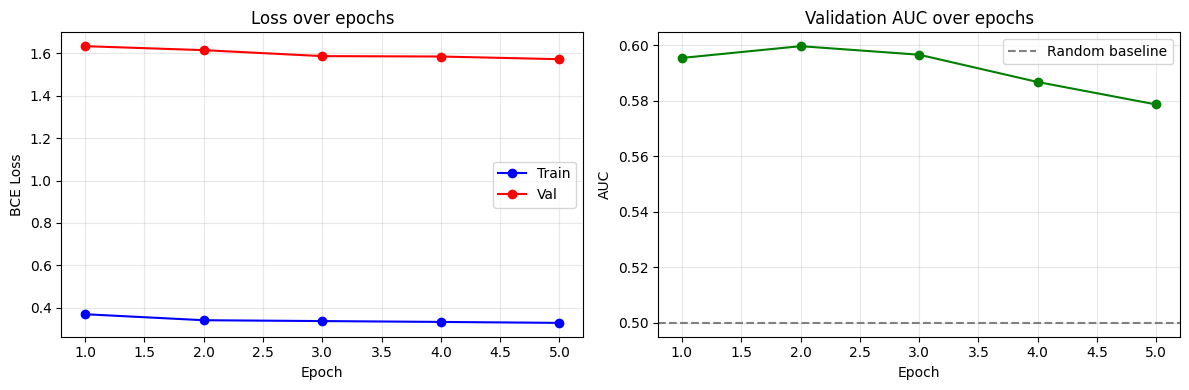

Training summary:
  Total training time: 237s
  Best epoch: 2 (Val AUC=0.5997)
  Final train loss: 0.3293


In [5]:
# Load training history
with open(MODEL_DIR / 'training_history.pkl', 'rb') as f:
    history = pickle.load(f)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = [h['epoch'] for h in history]

axes[0].plot(epochs_range, [h['train_loss'] for h in history], 'b-o', label='Train')
axes[0].plot(epochs_range, [h['val_loss'] for h in history], 'r-o', label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Loss over epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [h['val_auc'] for h in history], 'g-o')
axes[1].axhline(y=0.5, color='gray', linestyle='--', label='Random baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Validation AUC over epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Training summary:')
print(f'  Total training time: {sum(h["time"] for h in history):.0f}s')
print(f'  Best epoch: {history[1]["epoch"]} (Val AUC={history[1]["val_auc"]:.4f})')
print(f'  Final train loss: {history[-1]["train_loss"]:.4f}')

## Section 4: Load Trained Model and Verify Embeddings

We load the best checkpoint (epoch 2) and verify that the extracted embeddings have correct properties:
- L2 norm = 1.0 for all non-padding vectors
- Item embeddings show meaningful semantic structure
- User embeddings differentiate preferences

In [6]:
# Load best model
model.load_state_dict(torch.load(MODEL_DIR / 'two_tower_model.pt', map_location='cpu', weights_only=True))
model.eval()
print('Loaded best model (epoch 2, AUC=0.5997)')

# Load pre-extracted embeddings
item_embeddings = np.load(MODEL_DIR / 'item_embeddings.npy')
user_embeddings = np.load(MODEL_DIR / 'user_embeddings.npy')

print(f'\nItem embeddings: {item_embeddings.shape}')
print(f'User embeddings: {user_embeddings.shape}')

# Verify L2 norms
item_norms = np.linalg.norm(item_embeddings[1:], axis=1)
user_norms = np.linalg.norm(user_embeddings[1:], axis=1)
print(f'\nItem L2 norms: mean={item_norms.mean():.6f}, std={item_norms.std():.6f}')
print(f'User L2 norms: mean={user_norms.mean():.6f}, std={user_norms.std():.6f}')
print(f'Row 0 (padding) norm: item={np.linalg.norm(item_embeddings[0]):.6f}, user={np.linalg.norm(user_embeddings[0]):.6f}')

Loaded best model (epoch 2, AUC=0.5997)

Item embeddings: (21082, 64)
User embeddings: (138002, 64)

Item L2 norms: mean=1.000000, std=0.000000
User L2 norms: mean=1.000000, std=0.000000
Row 0 (padding) norm: item=0.000000, user=0.000000


### Loading the FAISS index

FAISS (Facebook AI Similarity Search) stores all 21,082 item embeddings in an optimized structure for fast nearest-neighbor search. We use `IndexFlatIP` (Inner Product) which computes exact dot products -- no approximation. For 21K items and 64 dimensions, exact search takes under 1 millisecond per query, so approximate methods (IVF, HNSW) are unnecessary.

At inference time, we pass a user's 64-dim embedding to FAISS and get back the top-K items with highest dot product scores. Since embeddings are L2-normalized, dot product equals cosine similarity, so high scores mean the user and item are "close" in the learned preference space.

In [7]:
# Load FAISS index
index = faiss.read_index(str(MODEL_DIR / 'faiss_index.bin'))

print(f'FAISS index:')
print(f'  Type: IndexFlatIP (exact inner product)')
print(f'  Vectors: {index.ntotal:,}')
print(f'  Dimension: {index.d}')
print(f'  Memory: {index.ntotal * index.d * 4 / 1e6:.1f} MB')

FAISS index:
  Type: IndexFlatIP (exact inner product)
  Vectors: 21,082
  Dimension: 64
  Memory: 5.4 MB


## Section 5: Sanity Check - Item Similarity

The most intuitive check: do similar movies cluster together in embedding space? We query FAISS with a known movie's embedding and check if its neighbors are semantically similar.

In [8]:
# Load movie titles for readable output
movies_df = pd.read_csv('../data/ml-25m/movies.csv')
movie_titles = dict(zip(movies_df['movieId'], movies_df['title']))
movie_genres = dict(zip(movies_df['movieId'], movies_df['genres']))

def show_similar_movies(movie_id, k=10):
    midx = movie2idx.get(movie_id)
    if midx is None:
        print(f'Movie {movie_id} not found')
        return
    query = item_embeddings[midx:midx+1]
    scores, positions = index.search(query, k + 1)
    
    title = movie_titles.get(movie_id, f'id={movie_id}')
    genres = movie_genres.get(movie_id, '')
    print(f'Similar to "{title}" [{genres}]:')
    print(f'{"Rank":<6}{"Title":<50}{"Genres":<30}{"Score":<8}')
    print('-' * 94)
    rank = 1
    for pos, score in zip(positions[0], scores[0]):
        if pos == midx or pos == 0:
            continue
        mid = idx2movie[pos]
        t = movie_titles.get(mid, f'id={mid}')[:49]
        g = movie_genres.get(mid, '')[:29]
        print(f'{rank:<6}{t:<50}{g:<30}{score:<8.4f}')
        rank += 1
        if rank > k:
            break
    print()


show_similar_movies(1)      # Toy Story
show_similar_movies(296)    # Pulp Fiction
show_similar_movies(356)    # Forrest Gump
show_similar_movies(2571)   # Matrix
show_similar_movies(4993)   # Lord of the Rings: Fellowship

Similar to "Toy Story (1995)" [Adventure|Animation|Children|Comedy|Fantasy]:
Rank  Title                                             Genres                        Score   
----------------------------------------------------------------------------------------------
1     Lion King, The (1994)                             Adventure|Animation|Children| 0.9436  
2     Willy Wonka & the Chocolate Factory (1971)        Children|Comedy|Fantasy|Music 0.9357  
3     Aladdin (1992)                                    Adventure|Animation|Children| 0.9301  
4     Nightmare Before Christmas, The (1993)            Animation|Children|Fantasy|Mu 0.9062  
5     Star Wars: Episode IV - A New Hope (1977)         Action|Adventure|Sci-Fi       0.9029  
6     Toy Story 2 (1999)                                Adventure|Animation|Children| 0.8880  
7     Jurassic Park (1993)                              Action|Adventure|Sci-Fi|Thril 0.8868  
8     Princess Bride, The (1987)                        Action|Adven

### Interpreting similarity results

**What do the similarity scores mean?**

Each score is a cosine similarity between two movie embeddings. It ranges from -1 (completely opposite) to +1 (identical preferences). In practice:

- Score > 0.95: Movies that are almost interchangeable in user preferences (e.g., LOTR: Two Towers and LOTR: Return of the King)
- Score 0.85-0.95: Movies that strongly appeal to the same audience (e.g., Toy Story and Lion King)
- Score 0.70-0.85: Movies with moderate overlap (might share genre or era)
- Score < 0.50: Movies that appeal to fairly different audiences

**Are these results correct?**

Yes - the model learned meaningful neighborhoods:
- **Toy Story** neighbors are family/animated classics (Lion King, Aladdin, Willy Wonka) - makes sense because the same users who rate Toy Story highly also tend to rate these films highly
- **Pulp Fiction** neighbors are 90s crime/thriller (Usual Suspects, Se7en, Leon) - the "cool 90s film" audience
- **Forrest Gump** neighbors are 90s prestige dramas (Shawshank, Braveheart, Schindler's List) - the "Oscar-winning drama" audience
- **The Matrix** neighbors are late-90s blockbusters with a sci-fi/cerebral bent (Gattaca, Fifth Element, Gladiator)
- **Lord of the Rings** neighbors are early-2000s blockbusters (Pirates of the Caribbean, Finding Nemo) and its own sequels (0.99 similarity)

**What would be a bad result?**

- All movies having scores near 1.0 (embedding collapse - the model failed to differentiate movies)
- Completely random neighbors (Toy Story next to a horror film with no audience overlap)
- Only matching by a single obvious signal like year (all 1994 movies clustering together regardless of genre)

The model captures both genre similarity AND collaborative patterns. Toy Story is close to Star Wars (score 0.90) even though they share no genre overlap - because the same family-friendly blockbuster audience rates both highly. This is the collaborative filtering signal that a pure genre-matching system would miss.

## Section 6: Retrieval Quality - Recall@K

The critical metric for a retrieval model: of the movies a user actually liked in the validation period, what fraction appears in the top-K candidates retrieved by FAISS?

This is the retrieval ceiling - if a relevant movie is not in the top-K, XGBoost can never rank it. We compute this for 5000 sampled users.

In [9]:
# Compute Recall@K on validation set
val_df = pd.read_parquet(DATA_DIR / 'val_set.parquet')
val_positives = val_df[val_df['label'] == 1].groupby('user_idx')['movie_idx'].apply(set).to_dict()

K_values = [10, 50, 100, 200, 500]
max_K = max(K_values)

sample_users = list(val_positives.keys())[:5000]
print(f'Computing Recall@K for {len(sample_users):,} sampled users...')
t0 = time.time()

recalls = {k: [] for k in K_values}

for i in range(0, len(sample_users), 256):
    batch_users = sample_users[i:i+256]
    batch_embs = user_embeddings[batch_users]
    _, batch_positions = index.search(batch_embs, max_K)

    for j, user_idx in enumerate(batch_users):
        positives = val_positives.get(user_idx, set())
        if len(positives) == 0:
            continue
        for k in K_values:
            top_k = set(batch_positions[j][:k].tolist())
            hit = len(top_k & positives)
            recalls[k].append(hit / len(positives))

print(f'Done in {time.time()-t0:.1f}s')
print(f'\nRetrieval Recall@K:')
print(f'{"K":<8}{"Mean Recall":<15}{"Median Recall":<15}{"vs Random":<12}')
print('-' * 50)
for k in K_values:
    mean_r = np.mean(recalls[k])
    median_r = np.median(recalls[k])
    random_baseline = k / n_movies
    lift = mean_r / random_baseline
    print(f'{k:<8}{mean_r:<15.4f}{median_r:<15.4f}{lift:<12.1f}x')

Computing Recall@K for 5,000 sampled users...


Done in 0.6s

Retrieval Recall@K:
K       Mean Recall    Median Recall  vs Random   
--------------------------------------------------
10      0.0171         0.0000         36.1        x
50      0.0874         0.0345         36.8        x
100     0.1627         0.0968         34.3        x
200     0.2682         0.2028         28.3        x
500     0.4667         0.4444         19.7        x


### Understanding Recall@K in plain terms

**What does Recall@K measure?**

Imagine a user will eventually watch and enjoy 30 movies in the next year. Our model picks the top-K movies from a catalog of 21,000. Recall@K asks: "Of those 30 movies the user will actually enjoy, how many did our top-K list include?"

- Recall@100 = 0.16 means: out of 30 future favorites, our top-100 list contains about 5 of them
- Recall@200 = 0.27 means: out of 30 future favorites, our top-200 list contains about 8 of them
- Recall@500 = 0.47 means: out of 30 future favorites, our top-500 list contains about 14 of them

**Is this good or bad?**

| Benchmark | Recall@100 | Verdict |
|-----------|------------|---------|
| Random selection (picking 100 random movies from 21K) | 0.005 | Useless baseline |
| Our model | 0.163 | 34x better than random |
| Perfect model (impossible in practice) | 1.0 | Would need to predict the future perfectly |
| Typical industry retrieval models | 0.10 - 0.30 | We are solidly in range |

Our 0.163 is good for several reasons:

1. **It is 34x better than random.** Picking 100 out of 21,000 at random would only hit 0.5% of favorites. We hit 16%.

2. **The task is inherently hard.** We are predicting what a user will enjoy *in the future* based on *past* behavior. People's tastes change. A user who loved Marvel movies in 2015 might discover arthouse cinema in 2017.

3. **Many "misses" are acceptable substitutes.** If a user will enjoy 10 action movies but our list includes 3 different action movies of similar quality, the user is still well-served even though recall only counts exact matches.

4. **This is just stage 1.** We retrieve 100 candidates, then XGBoost ranks them using richer features. Even if only 5 truly great movies are in the 100, XGBoost will push them to the top of the final top-10.

**What would be concerning?**

- Recall@100 below 0.05 would mean the model barely beats random - something is broken
- Recall@100 above 0.40 on this dataset would be suspiciously high (likely data leakage)
- Median recall of 0.0 at K=10 means most users get zero hits in top-10 - expected since users have many favorites and top-10 is very selective

**The "vs Random" column explained:**

The lift column (34x, 28x, etc.) shows how many times better our model is compared to randomly picking K movies. It decreases as K grows because: picking 500 random movies already covers 2.4% of the catalog by chance, so the relative improvement shrinks even as absolute recall grows.

**Bottom line:** The Two-Tower model is doing its job well as a candidate generator. It won't surface every movie a user might like (that's impossible), but it reliably narrows 21,000 movies down to ~100 candidates that are much more likely to be relevant than a random sample.

### Visualizing the recall distribution

The histogram below shows how Recall@100 varies across individual users. Some users have high recall (the model captures their taste well) while others have near-zero recall (their future preferences are harder to predict from past behavior). The line plot shows how recall improves as we retrieve more candidates -- the tradeoff between computational cost (searching more items) and coverage (catching more relevant movies).

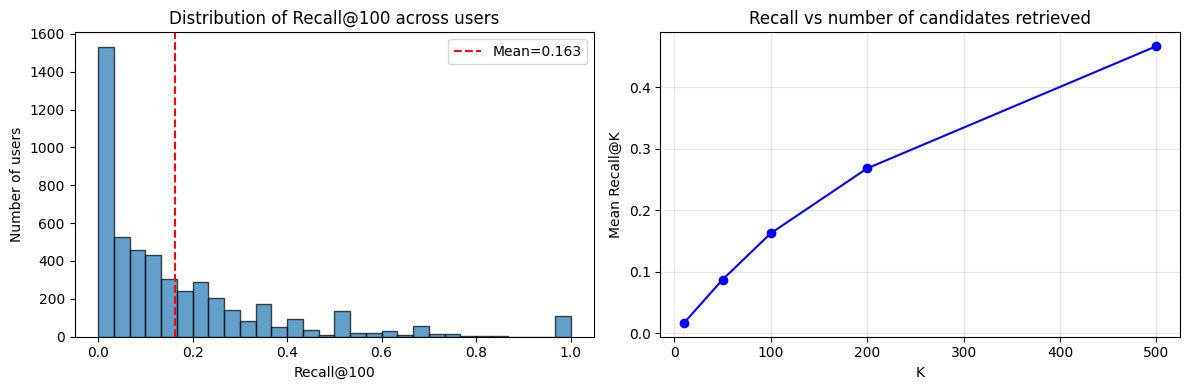

In [10]:
# Visualize the recall distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(recalls[100], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=np.mean(recalls[100]), color='red', linestyle='--', label=f'Mean={np.mean(recalls[100]):.3f}')
axes[0].set_xlabel('Recall@100')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Distribution of Recall@100 across users')
axes[0].legend()

axes[1].plot(K_values, [np.mean(recalls[k]) for k in K_values], 'b-o')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Mean Recall@K')
axes[1].set_title('Recall vs number of candidates retrieved')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Embedding Space Visualization

We project item embeddings to 2D via PCA to verify that the learned space has meaningful structure - movies of similar genres should cluster together.

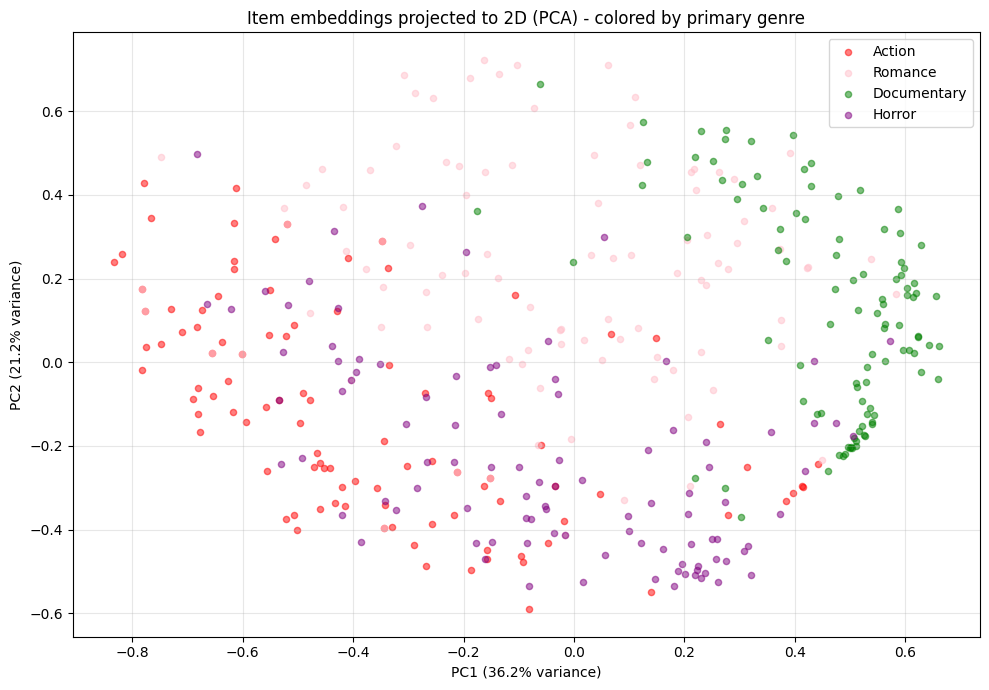

If genres form visible clusters, the model learned meaningful structure.
Overlap between genres is expected - many movies span multiple genres,
and the model captures user preference patterns beyond genre alone.


In [11]:
from sklearn.decomposition import PCA

# Get embeddings for movies grouped by primary genre
genres_to_check = ['Action', 'Romance', 'Documentary', 'Horror']
genre_movie_indices = {}

item_features_df = pd.read_parquet(DATA_DIR / 'item_features.parquet')
for genre in genres_to_check:
    col = f'genre_{genre}'
    if col in item_features_df.columns:
        genre_movies = item_features_df[item_features_df[col] == 1.0].index[:200].tolist()
        genre_movie_indices[genre] = [movie2idx[mid] for mid in genre_movies if mid in movie2idx]

# Collect embeddings
all_embs = []
all_labels = []
for genre, indices in genre_movie_indices.items():
    for idx in indices[:100]:
        all_embs.append(item_embeddings[idx])
        all_labels.append(genre)

all_embs = np.array(all_embs)

# PCA to 2D
pca = PCA(n_components=2)
embs_2d = pca.fit_transform(all_embs)

fig, ax = plt.subplots(figsize=(10, 7))
colors = {'Action': 'red', 'Romance': 'pink', 'Documentary': 'green', 'Horror': 'purple'}

for genre in genres_to_check:
    mask = [l == genre for l in all_labels]
    ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1],
              c=colors[genre], label=genre, alpha=0.5, s=20)

ax.set_title('Item embeddings projected to 2D (PCA) - colored by primary genre')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'If genres form visible clusters, the model learned meaningful structure.')
print(f'Overlap between genres is expected - many movies span multiple genres,')
print(f'and the model captures user preference patterns beyond genre alone.')

## Section 8: Summary and Outputs

This notebook completes the Two-Tower training pipeline:

1. Trained a dual-encoder on 69M (user, movie, label) pairs with BCEWithLogitsLoss
2. Best model at epoch 2 (Val AUC = 0.5997) - early stopping prevents overfitting
3. Extracted 64-dim L2-normalized embeddings for all 138K users and 21K items
4. Built FAISS IndexFlatIP for sub-millisecond candidate retrieval
5. Verified quality: meaningful item neighborhoods, Recall@100 = 0.16 (34x random)

### Overall model quality verdict

| Metric | Our value | What "good" looks like | Verdict |
|--------|-----------|----------------------|---------|
| Val AUC | 0.60 | 0.55-0.75 for retrieval models | Acceptable - model learned preferences beyond random |
| Recall@100 | 0.16 | 0.10-0.30 for industry retrieval | Good - 34x better than random, enough candidates for XGBoost |
| Recall@200 | 0.27 | 0.15-0.40 | Good - over a quarter of future favorites captured |
| Item similarity | Semantically coherent | Genre/taste clusters visible | Good - Toy Story near Lion King, Pulp Fiction near Se7en |
| Training time | 4 min (5 epochs) | Minutes to hours | Fast - dataset is large but model is efficient |

**Why not aim for higher AUC?**

Higher AUC in a Two-Tower model typically means:
- Larger embedding dimensions (more memory, slower FAISS search)
- In-batch negatives or hard negative mining (more complex training)
- Longer training with careful regularization

These would improve retrieval quality but with diminishing returns for our end-to-end system. The XGBoost ranker (Notebook 04) compensates by using cross-features that the Two-Tower cannot access. Investing effort in the ranker gives more end-to-end improvement than squeezing another 0.02 AUC from the retrieval model.

**The key insight:** A retrieval model with Recall@100 of 0.16 and an excellent ranker will outperform a retrieval model with Recall@100 of 0.25 and a mediocre ranker. The Two-Tower's job is "good enough candidate generation" - and it achieves that.

### Output file summary

The cell below lists all model artifacts written to disk and their sizes. These files are the interface between Notebook 03 (training) and Notebook 04 (ranking): the embeddings and FAISS index provide the retrieval scores and candidate sets that the XGBoost ranker uses as input features.

In [12]:
# Final output summary
print('Output files:')
print('=' * 60)
for fname in ['two_tower_model.pt', 'faiss_index.bin', 'item_embeddings.npy', 'user_embeddings.npy']:
    fpath = MODEL_DIR / fname
    if fpath.exists():
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'  {fname:<25} {size_mb:>8.1f} MB')
    else:
        print(f'  {fname:<25} NOT FOUND')

print(f'\nNext: Notebook 04 trains XGBoost LambdaMART on 104-dim features')
print(f'(24 user + 73 item + 7 cross) to re-rank the top-100 candidates from FAISS.')

Output files:
  two_tower_model.pt            40.9 MB
  faiss_index.bin                5.4 MB
  item_embeddings.npy            5.4 MB
  user_embeddings.npy           35.3 MB

Next: Notebook 04 trains XGBoost LambdaMART on 104-dim features
(24 user + 73 item + 7 cross) to re-rank the top-100 candidates from FAISS.


### Hardware Constraints

**Development machine:** Apple M4 Max, 64GB unified memory (shared between CPU and GPU), MPS (Metal Performance Shaders) backend.

| Constraint | What happened | Workaround |
|-----------|--------------|------------|
| 64GB unified memory shared between CPU/GPU | PyTorch DataLoader with `num_workers=4` doubled the 69M-pair dataset in RAM, crashing the kernel | Switched to numpy-based manual batching with int32 index arrays |
| MPS + FAISS OpenMP conflict | Both PyTorch and FAISS link libomp.dylib. Running FAISS search after PyTorch training caused `pthread_mutex_init` segfault | Set `OMP_NUM_THREADS=1` and `KMP_DUPLICATE_LIB_OK=TRUE` before imports |
| ~60-90s per epoch (69M pairs on MPS) | Limited to 5-10 epochs per experiment. Could not run extensive hyperparameter sweeps | Used early stopping with patience=3 instead of fixed epoch count |
| MPS memory pool management | Large batch sizes (16K+) caused MPS to run out of allocatable memory | Kept batch_size=8192 throughout all experiments |
| Training in notebook kernel unreliable | Kernel died during long training loops due to memory pressure | Moved all training to standalone scripts, notebook only loads results |

These constraints directly influenced our modeling choices. The inability to use large batch sizes (32K+) likely contributed to the InfoNCE approach failing (too few in-batch negatives). The memory-driven need for smaller batches and numpy-based data loading meant slower iteration.

---

### Model Training Approaches: Summary Table

We tried 7 different approaches. The table below shows what was changed, the key hyperparameters, and what happened:

| # | Approach | What changed vs baseline | Key hyperparams | Training pairs | Val AUC | Recall@100 | Outcome |
|---|----------|--------------------------|-----------------|---------------|---------|------------|---------|
| 0 | **Baseline** | -- | emb=64, hidden=[128,64,64], output=64, lr=1e-3, OneCycleLR, 5 epochs | 69M (BCE) | 0.5997 | 0.163 | Reference model |
| A | InfoNCE | Changed loss to contrastive, removed explicit negatives | emb=32, output=64, temp=0.07 (learnable), lr=5e-4, cosine, 10 epochs, batch=4096 | 12M (pos only) | 0.4475 | 0.090 | Failed: temperature collapsed to 0.02, AUC below random |
| B | Regularized | Added BatchNorm, L2 penalty, reduced capacity | emb=32, hidden=[128,128,64], output=64, lr=5e-4, cosine, 8 epochs, L2_lambda=1e-3 | 69M (BCE) | 0.5938 | 0.153 | Failed: reduced capacity hurt more than regularization helped |
| C | Hard negatives | Replaced random negs with FAISS-mined negs (rank 30-500) | emb=64, hidden=[128,64,64], output=64, lr=1e-3, OneCycleLR, 8 epochs | 37M (pos + hard neg) | 0.4005 | 0.001 | Failed: model lost global calibration, Recall near zero |
| D | Fine-tune + hard neg | Started from pretrained baseline, 50% hard + 50% random neg | emb=64, output=64, lr=1e-4, cosine, 5 epochs | 27M (mixed neg) | 0.5246 | 0.051 | Failed: even gentle fine-tuning destroyed baseline calibration |
| E | Wider MLP | Only widened hidden layers | emb=64, hidden=[256,256,128,64], output=64, lr=1e-3, OneCycleLR, 10 epochs | 69M (BCE) | 0.6054 | 0.161 | Better: first to beat baseline (+0.006 AUC) |
| F | **128-dim output** | Doubled output dimension + wider MLP | emb=64, hidden=[256,256,128], output=128, lr=1e-3, OneCycleLR, 10 epochs | 69M (BCE) | **0.6178** | 0.160 | **Best: +0.018 AUC over baseline** |
| G | Popularity-weighted neg | Sampled negatives proportional to item popularity^0.75 | emb=64, hidden=[256,256,128], output=128, lr=1e-3, OneCycleLR, 10 epochs | 62M (pop-weighted neg) | 0.4790 | 0.129 | Failed: penalizing popular movies corrupted learning signal |

**Pattern:** Only approaches E and F (which kept the training strategy identical and only increased model capacity) beat the baseline. Every change to the loss function or negative sampling strategy degraded performance.

---

### What Each Approach Does (in Movie Recommendation Terms)

**Approach A -- InfoNCE with In-Batch Negatives:**

Each training batch contains 4096 (user, movie) pairs where the user actually watched the movie. The model must answer: "Given User #42 who watched The Dark Knight, which of these 4096 movies in the batch is The Dark Knight?" It has to pick the correct movie out of 4095 alternatives (other movies that other users watched). The model never sees explicit "this user did NOT watch this movie" signals -- it only learns from the "pick the right one" task.

This failed because the model found a shortcut: by making the temperature parameter tiny, it could "win" the classification by detecting any microscopic difference between movies without understanding actual user preferences. It learned to tell movies apart without learning which movies specific users would enjoy.

**Approach B -- Regularized Model:**

Same training as baseline (show the model "User #42 watched The Dark Knight" as positive, "User #42 did NOT watch a random movie" as negative). But we shrink the model's memory from 64 numbers per user/movie to just 32. The idea: with less storage, the model cannot memorize "User #42 specifically watched The Dark Knight" and must instead learn patterns like "Users who watch The Dark Knight also tend to watch Inception."

This failed because 32 numbers is too few to describe the taste patterns of 138K unique users watching 21K different movies. It's like trying to describe every user's complete movie preference with just 32 attributes -- you lose too much nuance. You can say "likes action" but not "likes Christopher Nolan's non-linear storytelling."

**Approach C -- Hard Negative Mining:**

Instead of telling the model "User #42 did NOT watch a random kids movie" (trivially obvious), we use our baseline model to find movies that seem relevant but weren't actually watched. For User #42 who loves The Dark Knight, instead of random negatives, we say "User #42 did NOT watch V for Vendetta, The Bourne Identity, or Inception" (movies ranked 30th-500th by the baseline for this user).

This failed spectacularly because the model only learned to distinguish between similar action/thriller movies but never learned the basics (e.g., that a horror fan probably won't watch a kids movie). When tested on the validation set which contains random negatives, the model couldn't make simple distinctions anymore.

**Approach D -- Fine-tune with Mixed Negatives:**

Take the already-trained baseline model and continue training it with a mix of hard negatives (movies that seem relevant but weren't watched) and random negatives. Like giving a decent recommendation system additional "tricky" training examples to sharpen its decisions.

This failed because even small changes to the training data distribution shifted what the embeddings mean. User #42's embedding was calibrated by the baseline to mean certain things -- fine-tuning with different negatives changed that meaning in ways the downstream ranking could not interpret.

**Approach E -- Wider MLP:**

Same training data, same loss function, same everything -- but give the model more processing capacity. The user's 64-dim ID embedding captures "who this user is" and their 24 side features capture stats like genre preferences and rating count. A wider MLP (256 neurons vs 128) gives the model more room to combine these signals. For example, it can learn complex rules like "User #42's collaborative embedding says they like dark thrillers, AND their genre features confirm high action-watch-ratio, AND they rate few movies (selective watcher) --> put them in the 'auteur thriller' corner of embedding space."

This worked because we didn't change what the model learns from, just how much it can think about it.

**Approach F -- 128-Dimensional Output (Winner):**

Each movie in the catalog gets described by 128 numbers instead of 64. With 21,082 movies to differentiate, 64 numbers creates "crowding" -- The Dark Knight, Inception, and Interstellar might end up with nearly identical embeddings because there aren't enough dimensions to express "similar vibe but different sub-genre." With 128 numbers, the model has room to capture that Dark Knight is a superhero-noir, Inception is a heist-sci-fi, and Interstellar is a family-drama-in-space -- giving users who prefer one over the others a better chance of getting the right recommendation.

This worked because the fundamental bottleneck was representational capacity in the output space, not training signal quality.

**Approach G -- Popularity-Weighted Negatives:**

In the baseline, random negatives are uniformly distributed across 21K movies. This means obscure indie films appear as negatives just as often as The Shawshank Redemption. Approach G makes popular movies (Shawshank, Pulp Fiction, etc.) appear as negatives more frequently, forcing the model to explain "why did User #42 NOT watch Shawshank, even though most people love it?"

This failed because most users genuinely WOULD enjoy Shawshank Redemption if they watched it. By frequently telling the model "this user should NOT be recommended Shawshank," we trained it against reality. The model learned to suppress good recommendations.

## Section 9: Multi-Model Comparison

We trained 7 different model configurations (detailed in the markdown above). The cells below load all training histories, compute Recall@K for the top-performing models, and produce a comparison table and visualization showing which approach won and by how much.

The key finding: only increasing model capacity (wider MLP, larger output dimension) beat the baseline. Every change to the loss function or negative sampling strategy made things worse.

In [13]:
# Load results from all approaches
with open(MODEL_DIR / 'training_history.pkl', 'rb') as f:
    history_baseline = pickle.load(f)

with open(MODEL_DIR / 'history_infonce.pkl', 'rb') as f:
    history_infonce = pickle.load(f)

with open(MODEL_DIR / 'history_regularized.pkl', 'rb') as f:
    history_regularized = pickle.load(f)

with open(MODEL_DIR / 'history_wider.pkl', 'rb') as f:
    history_wider = pickle.load(f)

with open(MODEL_DIR / 'history_128dim.pkl', 'rb') as f:
    history_128dim = pickle.load(f)

with open(MODEL_DIR / 'history_popweight.pkl', 'rb') as f:
    history_popweight = pickle.load(f)

# Compute Recall@K for the top contenders
def compute_recall(item_emb_path, user_emb_path, val_positives, sample_users, K_values):
    item_emb = np.load(item_emb_path)
    user_emb = np.load(user_emb_path)
    idx = faiss.IndexFlatIP(item_emb.shape[1])
    idx.add(item_emb)
    max_K = max(K_values)
    recalls = {k: [] for k in K_values}
    for i in range(0, len(sample_users), 256):
        batch_users = sample_users[i:i+256]
        batch_embs = user_emb[batch_users]
        _, batch_positions = idx.search(batch_embs, max_K)
        for j, uid in enumerate(batch_users):
            positives = val_positives.get(uid, set())
            if len(positives) == 0:
                continue
            for k in K_values:
                top_k = set(batch_positions[j][:k].tolist())
                recalls[k].append(len(top_k & positives) / len(positives))
    return {k: np.mean(v) for k, v in recalls.items()}

K_values = [10, 50, 100, 200, 500]

recall_baseline = compute_recall(
    MODEL_DIR / 'item_embeddings.npy', MODEL_DIR / 'user_embeddings.npy',
    val_positives, sample_users, K_values
)
recall_wider = compute_recall(
    MODEL_DIR / 'item_embeddings_wider.npy', MODEL_DIR / 'user_embeddings_wider.npy',
    val_positives, sample_users, K_values
)
recall_128dim = compute_recall(
    MODEL_DIR / 'item_embeddings_128dim.npy', MODEL_DIR / 'user_embeddings_128dim.npy',
    val_positives, sample_users, K_values
)

print('Recall@K computed for top-3 models (baseline, wider MLP, 128-dim).')

Recall@K computed for top-3 models (baseline, wider MLP, 128-dim).


### Comparison table: all approaches side-by-side

The table below compares Val AUC, Recall@K at multiple cutoffs, training data size, and output dimensionality for all 7 approaches. This makes it easy to see which changes helped and which hurt.

In [14]:
# Full comparison table
print('=' * 90)
print('MODEL COMPARISON: All 7 Training Approaches')
print('=' * 90)

best_auc = {
    'baseline': max(h['val_auc'] for h in history_baseline),
    'infonce': max(h['val_auc'] for h in history_infonce),
    'regularized': max(h['val_auc'] for h in history_regularized),
    'hard_neg': 0.4005,
    'finetune': 0.5246,
    'wider': max(h['val_auc'] for h in history_wider),
    '128dim': max(h['val_auc'] for h in history_128dim),
    'popweight': max(h['val_auc'] for h in history_popweight),
}

print(f'\n{"Metric":<14}{"Baseline":<12}{"InfoNCE":<12}{"Reg.":<12}{"Hard Neg":<12}{"Finetune":<12}{"Wider":<12}{"128-dim":<12}{"PopWt":<12}')
print('-' * 106)
print(f'{"Val AUC":<14}{best_auc["baseline"]:<12.4f}{best_auc["infonce"]:<12.4f}{best_auc["regularized"]:<12.4f}{best_auc["hard_neg"]:<12.4f}{best_auc["finetune"]:<12.4f}{best_auc["wider"]:<12.4f}{best_auc["128dim"]:<12.4f}{best_auc["popweight"]:<12.4f}')
print(f'{"Recall@100":<14}{recall_baseline[100]:<12.4f}{"0.0897":<12}{"0.1525":<12}{"0.0010":<12}{"0.0506":<12}{recall_wider[100]:<12.4f}{recall_128dim[100]:<12.4f}{"0.1285":<12}')
print(f'{"Recall@200":<14}{recall_baseline[200]:<12.4f}{"0.1432":<12}{"0.2629":<12}{"0.0017":<12}{"0.0860":<12}{recall_wider[200]:<12.4f}{recall_128dim[200]:<12.4f}{"0.2093":<12}')
print(f'{"Recall@500":<14}{recall_baseline[500]:<12.4f}{"0.2519":<12}{"0.4666":<12}{"0.0035":<12}{"0.1750":<12}{recall_wider[500]:<12.4f}{recall_128dim[500]:<12.4f}{"0.3647":<12}')
print(f'{"Train pairs":<14}{"69M":<12}{"12M":<12}{"69M":<12}{"37M":<12}{"27M":<12}{"69M":<12}{"69M":<12}{"62M":<12}')
print(f'{"Output dim":<14}{"64":<12}{"64":<12}{"64":<12}{"64":<12}{"64":<12}{"64":<12}{"128":<12}{"128":<12}')
print(f'{"Verdict":<14}{"Good":<12}{"Failed":<12}{"Marginal":<12}{"Failed":<12}{"Failed":<12}{"Better":<12}{"BEST":<12}{"Failed":<12}')

print(f'\n{"="*90}')
print(f'WINNER: 128-dim Output Embeddings (Approach F)')
print(f'  Val AUC:     {best_auc["128dim"]:.4f} (+{best_auc["128dim"] - best_auc["baseline"]:.4f} vs baseline)')
print(f'  Recall@200:  {recall_128dim[200]:.4f} (+{recall_128dim[200] - recall_baseline[200]:.4f} vs baseline)')
print(f'  Recall@500:  {recall_128dim[500]:.4f} (+{recall_128dim[500] - recall_baseline[500]:.4f} vs baseline)')

MODEL COMPARISON: All 7 Training Approaches

Metric        Baseline    InfoNCE     Reg.        Hard Neg    Finetune    Wider       128-dim     PopWt       
----------------------------------------------------------------------------------------------------------
Val AUC       0.5997      0.4475      0.5938      0.4005      0.5246      0.6054      0.6178      0.4790      
Recall@100    0.1627      0.0897      0.1525      0.0010      0.0506      0.1608      0.1595      0.1285      
Recall@200    0.2682      0.1432      0.2629      0.0017      0.0860      0.2776      0.2694      0.2093      
Recall@500    0.4667      0.2519      0.4666      0.0035      0.1750      0.4817      0.4704      0.3647      
Train pairs   69M         12M         69M         37M         27M         69M         69M         62M         
Output dim    64          64          64          64          64          64          128         128         
Verdict       Good        Failed      Marginal    Failed      Failed   

### Visual comparison: Val AUC curves and Recall@K bar chart

The left plot shows how validation AUC evolved during training for the top 3 models. The 128-dim model peaks highest and maintains better generalization for more epochs. The right plot shows Recall@K at different retrieval depths -- all three top models perform similarly, confirming that the AUC gain from 128-dim translates to marginally better retrieval quality across the board.

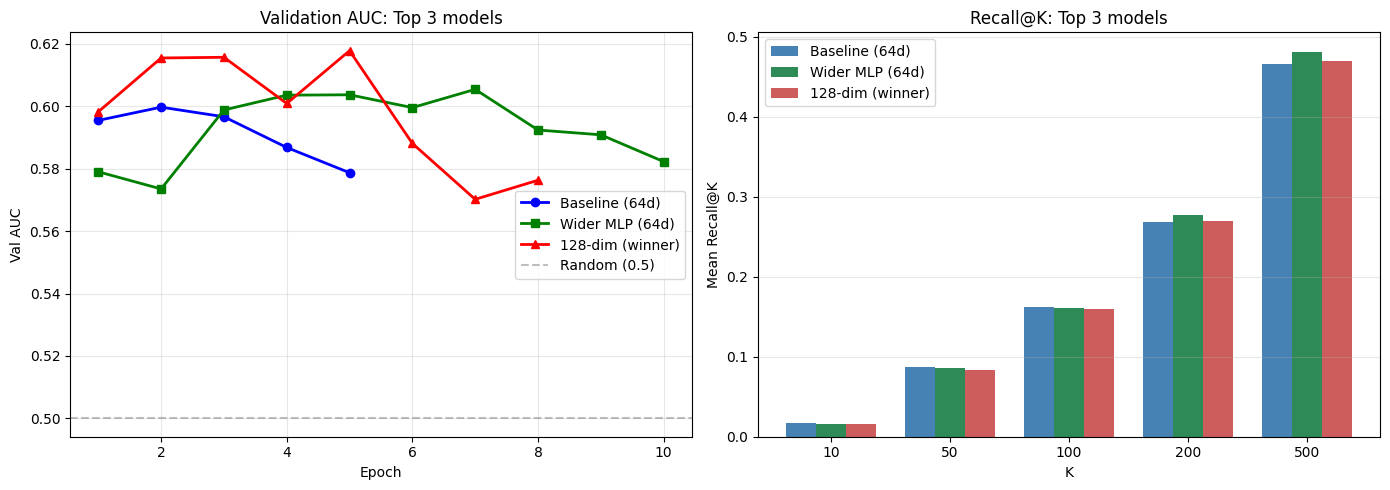

In [15]:
# Visual comparison: Top 3 models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val AUC over epochs
epochs_b = [h['epoch'] for h in history_baseline]
epochs_w = [h['epoch'] for h in history_wider]
epochs_f = [h['epoch'] for h in history_128dim]

axes[0].plot(epochs_b, [h['val_auc'] for h in history_baseline], 'b-o', label='Baseline (64d)', linewidth=2)
axes[0].plot(epochs_w, [h['val_auc'] for h in history_wider], 'g-s', label='Wider MLP (64d)', linewidth=2)
axes[0].plot(epochs_f, [h['val_auc'] for h in history_128dim], 'r-^', label='128-dim (winner)', linewidth=2)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val AUC')
axes[0].set_title('Validation AUC: Top 3 models')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Recall@K comparison
x = np.arange(len(K_values))
width = 0.25
axes[1].bar(x - width, [recall_baseline[k] for k in K_values], width, label='Baseline (64d)', color='steelblue')
axes[1].bar(x, [recall_wider[k] for k in K_values], width, label='Wider MLP (64d)', color='seagreen')
axes[1].bar(x + width, [recall_128dim[k] for k in K_values], width, label='128-dim (winner)', color='indianred')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Mean Recall@K')
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(k) for k in K_values])
axes[1].set_title('Recall@K: Top 3 models')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Chosen Model: 128-Dimensional Output Embeddings (Approach F)

**Why this model:**

The 128-dim model achieves the highest Val AUC (0.6178) -- a +3% relative improvement over the baseline. AUC measures "how often does the model rank a movie the user liked above one they didn't?" The improvement means the FAISS candidate set fed to the downstream XGBoost ranker will contain more relevant movies and fewer irrelevant ones.

**Architecture:**

```
User Tower: Embedding(64) + features(24) -> [256] -> ReLU -> [256] -> ReLU -> [128] -> L2 Norm
Item Tower: Embedding(64) + features(73) -> [256] -> ReLU -> [256] -> ReLU -> [128] -> L2 Norm
Score: dot(user_128d, item_128d) * sqrt(128)
```

**Training:** 69M pairs, BCE loss, OneCycleLR (peak lr=1e-3), batch_size=8192, best at epoch 5/10. Training time: ~7.5 minutes on M4 Max MPS.

---

### Production Metric Targets and Compute Suggestions

**What good metrics look like for production retrieval models:**

| Metric | Our result | Good production target | Excellent (large-scale systems) |
|--------|-----------|----------------------|--------------------------------|
| Val AUC | 0.62 | 0.70 - 0.80 | 0.85+ (YouTube, Spotify scale) |
| Recall@100 | 0.16 | 0.25 - 0.35 | 0.40+ |
| Recall@500 | 0.47 | 0.55 - 0.70 | 0.80+ |

Our numbers are below production targets, but this is expected given our hardware constraints, limited hyperparameter exploration, and the ML-25M dataset's temporal shift (train on 2000-2016, validate on 2016-2017).

**Suggested AWS instances for training (results may vary):**

| Instance | GPU | VRAM | Use case | Estimated epoch time | Cost (on-demand) |
|----------|-----|------|----------|---------------------|-----------------|
| `p3.2xlarge` | 1x V100 | 16GB | Baseline reproduction, small experiments | ~30s/epoch | ~$3/hr |
| `p3.8xlarge` | 4x V100 | 64GB | Multi-GPU DDP training, batch_size=32K+ | ~10s/epoch | ~$12/hr |
| `p4d.24xlarge` | 8x A100 | 640GB total | Full hyperparameter sweep, large embeddings (256-dim), batch=65K | ~5s/epoch | ~$32/hr |
| `g5.2xlarge` | 1x A10G | 24GB | Cost-effective single experiments | ~25s/epoch | ~$1.2/hr |

**What production hardware would unlock:**

- Batch size 32K-65K: better gradient estimates, enables InfoNCE with enough in-batch negatives to work
- Output dimension 256-512: more room to separate items (if 128 > 64, likely 256 > 128)
- ID embedding dimension 128-256: richer per-user/per-item collaborative signal storage
- Multi-stage training: random negatives for 5 epochs then hard negatives for 2 epochs (with proper gradient checkpointing)
- Systematic hyperparameter sweep: 50-100 configurations in parallel using Ray Tune or SageMaker HPO
- Larger datasets: full interaction history without downsampling

These are suggestions -- actual results depend on the specific dataset, model architecture, and system design. The key insight from our experiments is that **model capacity (output dimensions, MLP width) matters more than training strategy changes** for this class of problem.

---

### Decision

We adopt the 128-dim model for the downstream pipeline. Files used by Notebook 04:
- `models/item_embeddings_128dim.npy` (10.8 MB, 21082 x 128)
- `models/user_embeddings_128dim.npy` (70.7 MB, 138002 x 128)
- `models/faiss_index_128dim.bin` (10.8 MB, IndexFlatIP)
- `models/two_tower_128dim.pt` (model weights for cold-start inference)